<a href="https://colab.research.google.com/github/sinnu2004/MLProjects/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np


In [4]:
df = pd.read_csv("/content/winequality-red.csv")

In [5]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [6]:
x = df.drop(columns=['quality'])
y = df['quality']

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [10]:
predict = model.predict(x_test)

In [11]:
predict

array([5.3 , 5.23, 5.46, 5.19, 6.  , 5.06, 5.13, 4.92, 6.14, 5.87, 6.75,
       5.27, 5.73, 5.3 , 5.47, 6.34, 5.42, 5.8 , 6.84, 5.06, 4.94, 5.86,
       5.36, 5.95, 5.59, 5.97, 6.44, 5.33, 5.31, 5.97, 5.33, 5.46, 5.9 ,
       5.56, 5.87, 5.14, 6.27, 6.01, 5.37, 6.05, 5.19, 5.14, 6.29, 5.08,
       5.57, 5.69, 6.32, 5.64, 5.18, 5.75, 5.06, 5.25, 5.63, 7.1 , 5.18,
       5.63, 5.95, 5.87, 5.65, 5.02, 5.68, 6.14, 5.5 , 5.32, 6.71, 5.35,
       6.67, 5.64, 6.7 , 5.5 , 6.08, 5.24, 5.8 , 5.58, 6.08, 5.05, 6.6 ,
       5.3 , 6.02, 6.6 , 5.19, 6.79, 5.17, 5.61, 5.8 , 6.47, 5.12, 5.97,
       6.53, 5.4 , 6.37, 5.57, 5.  , 5.27, 5.23, 5.41, 5.11, 5.94, 4.6 ,
       5.5 , 5.08, 5.02, 5.8 , 6.43, 5.55, 6.69, 5.83, 5.21, 5.45, 5.22,
       6.48, 5.02, 6.4 , 5.02, 5.28, 6.13, 5.33, 5.29, 5.1 , 5.88, 6.13,
       5.76, 5.81, 5.36, 5.73, 5.29, 6.38, 5.51, 5.2 , 5.6 , 5.8 , 5.35,
       5.03, 6.32, 5.75, 5.06, 4.89, 5.38, 5.16, 5.91, 6.61, 6.21, 6.49,
       5.37, 5.51, 5.11, 5.52, 5.59, 5.61, 5.09, 5.

In [12]:
res = pd.DataFrame({'Actual':y_test,'Predicted':predict})

In [13]:
res

,Actual,Predicted
803,6,5.30
124,5,5.23
350,6,5.46
682,5,5.19
1326,6,6.00
...,...,...
1259,6,5.89
1295,5,4.96
1155,5,5.11
963,6,6.33


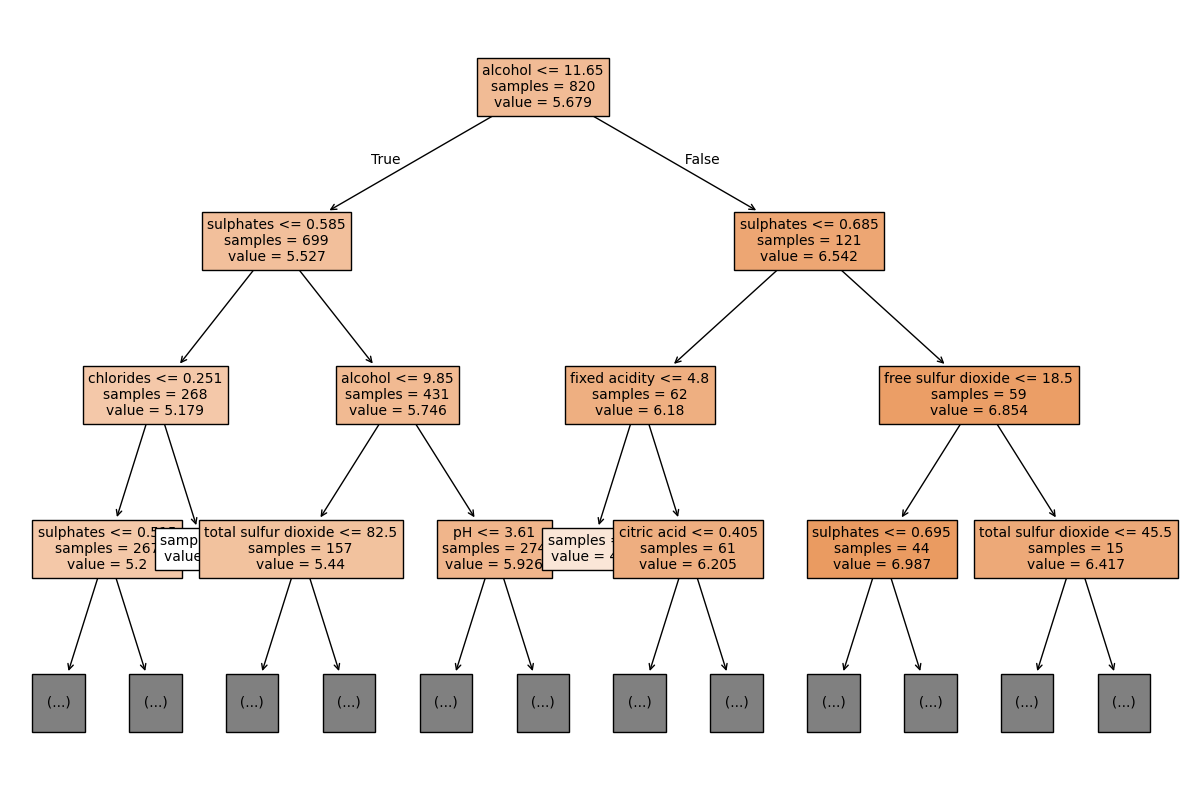

In [22]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(
    model.estimators_[0],
    feature_names=x.columns,
    filled=True,
    impurity=False,
    fontsize=10,
    max_depth=3
)
plt.show()

In [23]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


In [25]:
print("MAE",mean_absolute_error(y_test,predict))
print("MSE",mean_squared_error(y_test,predict))
print("RMSE",np.sqrt(mean_squared_error(y_test,predict)))
print("R2",r2_score(y_test,predict))

MAE 0.4224375
MSE 0.30123812499999997
RMSE 0.5488516420673258
R2 0.5390429623873638


In [27]:
print("Training Accuracy", model.score(x_train,y_train)*100)
print("Testing Accuracy",model.score(x_test,y_test)*100)

Training Accuracy 92.65672153390224
Testing Accuracy 53.90429623873638
